<h2 style='color:blue' align='center'>Small Image Classification Using Convolutional Neural Network (CNN)</h2>

- In this notebook, we will classify small images cifar10 dataset from tensorflow keras datasets. There are total 10 classes as shown below. We will use CNN for classification

- Here data are of 10 types and we need to segragate images to below 10 classes

<img src="small_images.jpg" />

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

<h4 style="color:purple">Load the dataset</h4>

- cifar10 is inbuilt dataset with 4 parts, if we read like below, it gives data set as (X_train, y_train), (X_test,y_test) 

In [2]:
(X_train, y_train), (X_test,y_test) = datasets.cifar10.load_data()
X_train.shape

170508288/170498071 [==============================] - 19s 0us/step


(50000, 32, 32, 3)

> It has 50k Images each are 32*32 dimention and RGB(3) form

In [3]:
X_test.shape

(10000, 32, 32, 3)

Here we see there are 50000 training images and 10000 test images

In [4]:
y_train.shape

(50000, 1)

In [63]:
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

- y_train is a 2D array, for our classification having 1D array is good enough. so we will convert this to now 1D array for both y_train and y_test

- Here reshape (-1), -1 means keeps all vallue of 1st D only as 1 array

In [64]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [65]:
y_test = y_test.reshape(-1,)

In [28]:
X_train[0]
# This is 32*32 dimension image with esch of 3 col(RGB)


array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]

In [29]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

### Let's plot some images to see what they are 

- Here plt.imshow plot the image
- xlabel will read the y value based on index and pass this to classes to show name 

In [30]:
def plot_sample(X, y, index):
    plt.figure(figsize = (15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

In [31]:
classes[y_train[0]]

'frog'

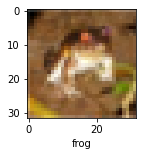

In [32]:
plot_sample(X_train, y_train, 0)

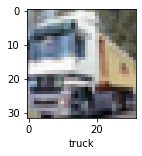

In [33]:
plot_sample(X_train, y_train, 1)

- Normalize the images to a number from 0 to 1. Image has 3 channels (R,G,B) and each value in the channel can range from 0 to 255. Hence to normalize in 0-->1 range, we need to divide it by 255

<h4 style="color:purple">Normalizing the training data</h4>

In [34]:
X_train = X_train / 255.0
X_test = X_test / 255.0

## 1. Build ANN
<h4 style="color:purple">Build simple artificial neural network for image classification</h4>

In [35]:
# Here o/p shape 3000,1000 are randomly selected. 10 is actually based on disting o/p class

ann = models.Sequential([
        layers.Flatten(input_shape=(32,32,3)),
        layers.Dense(3000, activation='relu'),
        layers.Dense(1000, activation='relu'),
        layers.Dense(10, activation='sigmoid')    
    ])

ann.compile(optimizer='SGD',
              loss='sparse_categorical_crossentropy', # as we have not done the one hot encodig for Y we are using sparse categorical if not we would have used 'catogorical_crossentropy'. Here o/p are 1 to 9 value
              metrics=['accuracy'])

ann.fit(X_train, y_train, epochs=5)

Epoch 1/5
1563/1563 [==============================] - 76s 49ms/step - loss: 1.8133 - accuracy: 0.3540
Epoch 2/5
1563/1563 [==============================] - 66s 42ms/step - loss: 1.6233 - accuracy: 0.4284
Epoch 3/5
1563/1563 [==============================] - 67s 43ms/step - loss: 1.5424 - accuracy: 0.4573
Epoch 4/5
1563/1563 [==============================] - 67s 43ms/step - loss: 1.4837 - accuracy: 0.4772
Epoch 5/5
1563/1563 [==============================] - 68s 43ms/step - loss: 1.4326 - accuracy: 0.4948


**You can see that at the end of 5 epochs, accuracy is at around 48.48%**

- Here Predicted value is array of 10 value, we need to consider max value as final prediction index for that class

In [36]:
from sklearn.metrics import confusion_matrix , classification_report
import numpy as np
y_pred = ann.predict(X_test)
print(y_pred)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("Classification Report: \n", classification_report(y_test, y_pred_classes))

[[0.21651459 0.6428187  0.7322287  ... 0.28030306 0.40280387 0.24281642]
 [0.525975   0.9732238  0.26521623 ... 0.27439457 0.89696234 0.99646115]
 [0.90741646 0.94424874 0.33726022 ... 0.515252   0.9130424  0.9832498 ]
 ...
 [0.05316499 0.06762987 0.7939899  ... 0.7563211  0.16000286 0.23121709]
 [0.19894668 0.27425823 0.75156665 ... 0.7375868  0.04497588 0.47703996]
 [0.34330803 0.36078304 0.6148567  ... 0.94949245 0.11136687 0.703829  ]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.73      0.26      0.39      1000
           1       0.64      0.44      0.52      1000
           2       0.43      0.24      0.31      1000
           3       0.40      0.16      0.23      1000
           4       0.64      0.15      0.24      1000
           5       0.35      0.43      0.39      1000
           6       0.55      0.47      0.51      1000
           7       0.29      0.74      0.42      1000
           8       0.78      0.27      0.40 

## 2. Build CNN

<h4 style="color:purple">Now let us build a convolutional neural network to train our images</h4>

- In CNN-Conv2D, we will define no of filters (filters=32) to be used, no need to give filter values, it will be set automatically during training
-  In CNN-Conv2D, kernel_size=(3, 3) is the size of filter. Its 3*3 dimension filter

- No of layers in DP, CNN are upto us, we need to decide based on trail and error method

In [37]:
cnn = models.Sequential([
    
    # 1st layer of CNN-Feature Mapping
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)), # Here converting output of previous layer from 3*3 dimension to 2*2 dimension by using 
    #kernel size means filter size i.e we are using 3*3 size filter. 
    
    # 2nd layer of CNN-Feature Mapping
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    #normal classification layer
    layers.Flatten(), # no need to mention the shape since it can auto detect due to previous steps
    layers.Dense(64, activation='relu'), # we kept only 1 hidden layer since most of the work would have done by CNN already in above
    layers.Dense(10, activation='softmax')
])

Softmax normalizes the probability. Eg lets say output was as below

class1 = 0.45 and class2 = 0.76 then Sigmoid gives as it is. No normalization is done

Whereas Softmax normalizes ie when we add it will be equal to 1.

class1 = 0.45/(0.45+0.76) = 0.401785714285
class2 = 0.76/(0.45+0.76) = 0.598214285714

In [39]:
cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [40]:
cnn.fit(X_train, y_train, epochs=10)

Epoch 1/10
1563/1563 [==============================] - 28s 18ms/step - loss: 1.4356 - accuracy: 0.4866
Epoch 2/10
1563/1563 [==============================] - 31s 20ms/step - loss: 1.0773 - accuracy: 0.6258
Epoch 3/10
1563/1563 [==============================] - 30s 19ms/step - loss: 0.9506 - accuracy: 0.6712
Epoch 4/10
1563/1563 [==============================] - 30s 19ms/step - loss: 0.8610 - accuracy: 0.7017
Epoch 5/10
1563/1563 [==============================] - 30s 19ms/step - loss: 0.7942 - accuracy: 0.7270
Epoch 6/10
1563/1563 [==============================] - 32s 20ms/step - loss: 0.7356 - accuracy: 0.7444
Epoch 7/10
1563/1563 [==============================] - 30s 19ms/step - loss: 0.6830 - accuracy: 0.7614
Epoch 8/10
1563/1563 [==============================] - 31s 20ms/step - loss: 0.6400 - accuracy: 0.7781
Epoch 9/10
1563/1563 [==============================] - 30s 19ms/step - loss: 0.5924 - accuracy: 0.7933
Epoch 10/10
1563/1563 [==============================] - 31s 20m

**With CNN, at the end 5 epochs, accuracy was at around 80.28% which is a significant improvement over ANN. CNN's are best for image classification and gives superb accuracy. Also computation is much less compared to simple ANN as maxpooling reduces the image dimensions while still preserving the features**

In [41]:
cnn.evaluate(X_test,y_test)

313/313 [==============================] - 2s 4ms/step - loss: 0.9119 - accuracy: 0.7053


[0.9118724465370178, 0.705299973487854]

In [42]:
y_pred = cnn.predict(X_test)
y_pred[:5]

array([[3.1188744e-04, 1.7154431e-04, 2.5615057e-03, 7.4988782e-01,
        3.8670551e-05, 2.4212214e-01, 1.2893855e-03, 1.8811865e-05,
        2.0300748e-03, 1.5682940e-03],
       [1.0652902e-05, 1.5134770e-04, 1.7967035e-10, 1.2494976e-09,
        1.3273152e-10, 1.4724742e-11, 1.0495511e-12, 2.7719395e-14,
        9.9983430e-01, 3.7091240e-06],
       [9.9528544e-02, 2.9989112e-02, 1.4116529e-03, 1.0191733e-03,
        1.6100662e-04, 5.4862635e-06, 4.4954741e-05, 3.9233657e-04,
        8.5920173e-01, 8.2460428e-03],
       [8.3389026e-01, 4.2576134e-02, 7.9646660e-03, 2.1802341e-03,
        5.8999605e-04, 1.0954565e-05, 1.0396916e-05, 3.4354827e-05,
        1.0941192e-01, 3.3311197e-03],
       [8.4283300e-08, 2.1316451e-05, 9.7127119e-03, 1.0318412e-02,
        7.3275939e-02, 1.0044060e-03, 9.0565854e-01, 1.5197431e-06,
        6.8709910e-06, 2.1696556e-07]], dtype=float32)

In [46]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[3, 8, 8, 0, 6]

In [47]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

> here its predicting exactly same as y_test

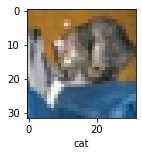

In [54]:
plot_sample(X_test, y_test,0)
# check x_test 3rd imagefrom y_test

In [55]:
classes[y_classes[0]]
# check x_test predicted 3rd image from y_classes

'cat'

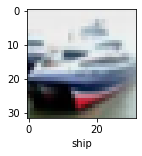

In [56]:
plot_sample(X_test, y_test,1)
# check x_test 3rd imagefrom y_test

In [57]:
classes[y_classes[1]]
# check x_test predicted 3rd image from y_classes

'ship'

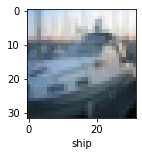

In [59]:
plot_sample(X_test, y_test,2)
# check x_test 3rd imagefrom y_test

In [60]:
classes[y_classes[2]]
# check x_test predicted 3rd image from y_classes

'ship'

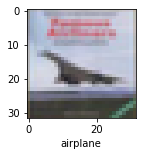

In [61]:
plot_sample(X_test, y_test,3)
# check x_test 3rd imagefrom y_test

In [62]:
classes[y_classes[3]]
# check x_test predicted 3rd image from y_classes

'airplane'

<h3 style='color:purple'>Exercise</h3>

Use CNN to do handwritten digits classification using MNIST dataset. You can use this notebook as a reference:
https://github.com/codebasics/py/blob/master/DeepLearningML/1_digits_recognition/digits_recognition_neural_network.ipynb

Above we used ANN for digits classification. You need to modify this code to use CNN instead. Check how accuracy improves fast with CNN and figure out how CNN can be a better choice for doing image classification compared to ANN. Once you have worked on this problem on your own, you can check my solution by clicking on this link: [Solution](https://github.com/codebasics/py/blob/master/DeepLearningML/16_cnn_cifar10_small_image_classification/cnn_mnist_exercise_solution.ipynb)